In [22]:
!pip install pyarrow 
!pip install matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np


In [2]:
yellow_taxi_jan_2026 = pd.read_parquet(r"D:\projects\data analysis\NYC Taxi Data Analysis\data\raw_data\yellow_tripdata_2026-01.parquet")

In [7]:
yellow_taxi_jan_2026.sample(n = 50000).to_csv("yellow_tripdata_2026-01.csv", index=False)

# Observer the data for `Dirty Data` and `Messy Data` and note down the issue 

In [11]:
yellow_taxi_jan_2026.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

In [8]:
yellow_taxi_jan_2026.sample(15)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1552021,2,2026-01-18 21:40:30,2026-01-18 21:51:44,2.0,2.11,1.0,N,161,234,1,13.50,1.0,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75
1946173,1,2026-01-23 09:43:20,2026-01-23 10:21:49,1.0,9.70,99.0,N,68,42,1,35.50,0.0,0.5,0.00,0.0,0.0,36.00,0.0,0.0,0.00
3643863,2,2026-01-30 18:44:27,2026-01-30 18:59:44,NaN,0.00,NaN,NaN,246,231,0,60.53,0.0,0.5,0.00,0.0,1.0,65.28,NaN,NaN,0.75
821290,2,2026-01-10 22:04:18,2026-01-10 22:11:32,2.0,1.51,1.0,N,239,237,1,10.00,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.00
702413,2,2026-01-09 18:49:46,2026-01-09 19:09:12,1.0,3.12,1.0,N,263,48,1,19.80,2.5,0.5,5.41,0.0,1.0,32.46,2.5,0.0,0.75
1322060,2,2026-01-16 10:04:53,2026-01-16 10:09:57,1.0,0.91,1.0,N,238,143,2,7.20,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0,0.00
2410187,1,2026-01-29 17:57:29,2026-01-29 18:03:56,2.0,0.50,1.0,N,236,263,1,7.20,5.0,0.5,2.74,0.0,1.0,16.44,2.5,0.0,0.00
2687496,2,2026-01-02 06:26:43,2026-01-02 06:56:03,NaN,13.64,NaN,NaN,148,78,0,49.33,0.0,0.5,0.00,0.0,1.0,54.08,NaN,NaN,0.75
2727791,2,2026-01-03 18:31:07,2026-01-03 18:45:59,NaN,4.52,NaN,NaN,42,127,0,20.18,0.0,0.5,0.00,0.0,1.0,21.68,NaN,NaN,0.00
852786,2,2026-01-11 11:32:13,2026-01-11 11:34:51,2.0,0.42,1.0,N,142,163,1,5.10,0.0,0.5,2.00,0.0,1.0,11.85,2.5,0.0,0.75


In [9]:
yellow_taxi_jan_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [12]:
yellow_taxi_jan_2026.duplicated().sum()

np.int64(0)

In [64]:
yellow_taxi_jan_2026.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

# column wise checking

-- VendorID

In [17]:
yellow_taxi_jan_2026['VendorID'].unique()

array([2, 1, 7, 6], dtype=int32)

<Axes: xlabel='VendorID'>

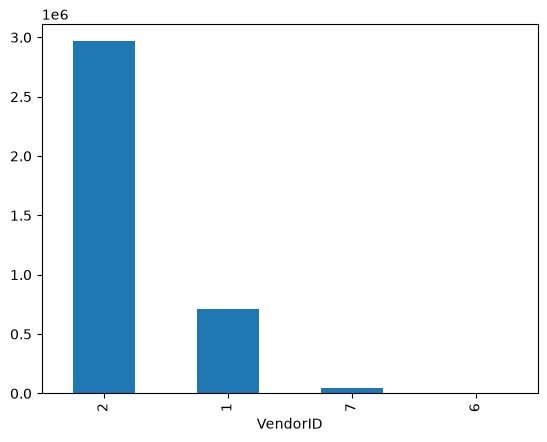

In [152]:
yellow_taxi_jan_2026['VendorID'].value_counts(dropna=False).plot(kind='bar')

-- tpep_pickup_datetime

In [69]:
yellow_taxi_jan_2026[
    ~((yellow_taxi_jan_2026['tpep_pickup_datetime'].dt.year == 2026) &
    (yellow_taxi_jan_2026['tpep_pickup_datetime'].dt.month == 1 ))
]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
980,2,2025-12-31 23:57:29,2025-12-31 23:57:32,2.0,0.01,2.0,N,132,264,3,-70.0,0.0,-0.5,0.00,0.0,-1.0,-71.50,0.0,0.00,0.00
981,2,2025-12-31 23:57:29,2025-12-31 23:57:32,2.0,0.01,2.0,N,132,264,3,70.0,0.0,0.5,0.00,0.0,1.0,71.50,0.0,0.00,0.00
982,2,2025-12-31 23:58:58,2026-01-01 01:04:39,2.0,40.14,3.0,N,132,1,2,167.2,1.0,0.0,0.00,27.0,1.0,198.70,0.0,1.75,0.75
1404,2,2025-12-31 23:57:54,2026-01-01 00:09:36,1.0,2.00,1.0,N,164,144,1,12.8,1.0,0.5,2.00,0.0,1.0,20.55,2.5,0.00,0.75
2289,2,2025-12-31 23:59:06,2026-01-01 00:16:43,1.0,0.43,1.0,N,163,48,2,14.9,1.0,0.5,0.00,0.0,1.0,20.65,2.5,0.00,0.75
5181,2,2025-12-31 23:58:45,2026-01-01 00:07:12,1.0,1.68,1.0,N,113,4,1,10.7,1.0,0.5,2.00,0.0,1.0,18.45,2.5,0.00,0.75
2635466,2,2026-02-01 00:45:01,2026-02-01 01:03:08,1.0,1.78,1.0,N,79,249,1,15.6,1.0,0.5,5.34,0.0,1.0,26.69,2.5,0.00,0.75


In [70]:
yellow_taxi_jan_2026['tpep_pickup_datetime'].describe()

count                       3724889
mean     2026-01-17 01:44:52.106518
min             2025-12-31 23:57:29
25%             2026-01-09 17:51:59
50%             2026-01-16 21:20:56
75%             2026-01-24 07:25:11
max             2026-02-01 00:45:01
Name: tpep_pickup_datetime, dtype: object

-- tpep_dropoff_datetime

In [73]:
yellow_taxi_jan_2026['tpep_dropoff_datetime'].describe()

count                       3724889
mean     2026-01-17 02:02:03.696138
min             2025-12-31 23:57:32
25%             2026-01-09 18:08:47
50%             2026-01-16 21:36:14
75%             2026-01-24 07:40:22
max             2026-02-01 23:35:31
Name: tpep_dropoff_datetime, dtype: object

-- passenger_count

In [76]:
yellow_taxi_jan_2026['passenger_count'].describe()

count    2.636831e+06
mean     1.256271e+00
std      6.702431e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [156]:
(
    yellow_taxi_jan_2026["passenger_count"].notna() &
    (yellow_taxi_jan_2026["passenger_count"] % 1 != 0)
).sum()


np.int64(0)

In [19]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['passenger_count']==9]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
212630,2,2026-01-03 21:27:58,2026-01-03 21:28:10,9.0,0.0,5.0,N,209,209,1,94.0,0.0,0.5,0.0,0.0,1.0,98.75,2.5,0.0,0.75


In [61]:
(yellow_taxi_jan_2026['passenger_count'] == 0).sum()

np.int64(14787)

Matplotlib is building the font cache; this may take a moment.


<Axes: >

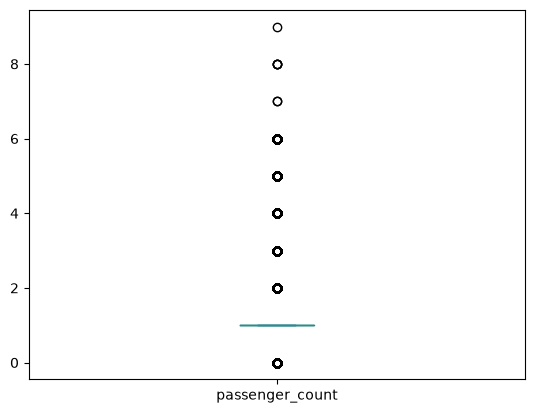

In [24]:
yellow_taxi_jan_2026['passenger_count'].plot(kind='box')

<Axes: ylabel='Frequency'>

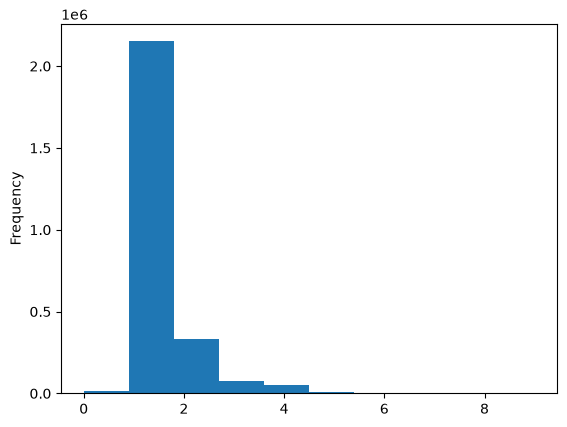

In [28]:
yellow_taxi_jan_2026['passenger_count'].plot(kind='hist')

In [30]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['passenger_count']>5]['passenger_count'].value_counts()

passenger_count
6.0    4887
8.0       4
7.0       2
9.0       1
Name: count, dtype: int64

-- trip_distance

In [32]:
yellow_taxi_jan_2026['trip_distance'].describe()

count    3.724889e+06
mean     6.455647e+00
std      6.488855e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.810000e+00
75%      3.730000e+00
max      2.690975e+05
Name: trip_distance, dtype: float64

<Axes: >

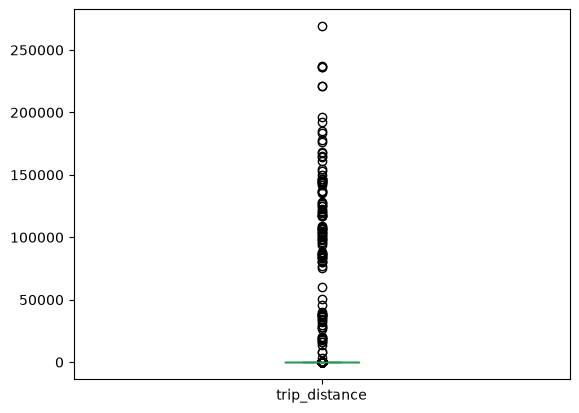

In [34]:
yellow_taxi_jan_2026['trip_distance'].plot(kind='box')

In [37]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['trip_distance'] > 350]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
77980,2,2026-01-02 10:20:45,2026-01-02 10:36:06,2.0,36610.27,4.0,N,138,170,2,105.27,0.0,0.0,0.00,6.94,0.0,117.21,2.5,1.75,0.75
1263708,2,2026-01-15 18:30:38,2026-01-15 18:40:15,3.0,8301.22,4.0,N,164,68,1,10.00,2.5,0.5,3.45,0.00,1.0,20.70,2.5,0.00,0.75
1500882,2,2026-01-18 09:52:01,2026-01-18 09:58:07,1.0,98773.58,5.0,N,179,146,1,7.10,0.0,0.5,0.00,0.00,1.0,8.60,0.0,0.00,0.00
2663467,2,2026-01-01 11:25:00,2026-01-01 11:34:00,NaN,136722.06,NaN,NaN,4,170,0,10.19,0.0,0.5,0.00,0.00,1.0,15.94,NaN,NaN,0.75
2666504,2,2026-01-01 12:54:00,2026-01-01 13:13:00,NaN,93929.48,NaN,NaN,36,260,0,31.62,0.0,0.5,0.00,0.00,1.0,33.12,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620632,2,2026-01-30 07:53:00,2026-01-30 08:25:00,NaN,142185.56,NaN,NaN,61,231,0,31.28,0.0,0.5,5.40,0.00,1.0,41.43,NaN,NaN,0.75
3625377,2,2026-01-30 09:12:00,2026-01-30 09:28:00,NaN,16338.51,NaN,NaN,79,88,0,35.20,0.0,0.5,0.00,0.00,1.0,39.95,NaN,NaN,0.75
3632367,2,2026-01-30 13:00:00,2026-01-30 13:38:00,NaN,237567.19,NaN,NaN,42,130,0,72.99,0.0,0.5,0.00,7.46,1.0,81.95,NaN,NaN,0.00
3634297,2,2026-01-30 14:18:00,2026-01-30 14:50:00,NaN,34816.24,NaN,NaN,212,220,0,31.68,0.0,0.5,0.00,0.00,1.0,33.18,NaN,NaN,0.00


-- RatecodeID

In [80]:
yellow_taxi_jan_2026['RatecodeID'].describe()

count    2.636831e+06
mean     5.218853e+00
std      1.965370e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.900000e+01
Name: RatecodeID, dtype: float64

In [42]:
yellow_taxi_jan_2026['RatecodeID'].unique()

array([ 1.,  4.,  2.,  5., 99.,  3.,  6., nan])

<Axes: xlabel='RatecodeID'>

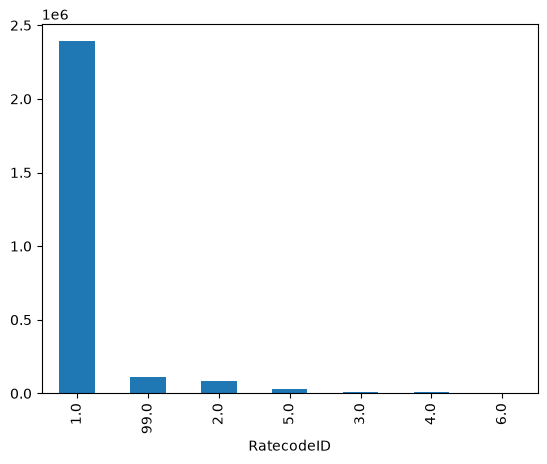

In [45]:
yellow_taxi_jan_2026['RatecodeID'].dropna().value_counts().plot(kind='bar')

-- store_and_fwd_flag

In [85]:
yellow_taxi_jan_2026['store_and_fwd_flag'].value_counts(dropna=False)

store_and_fwd_flag
N      2634494
NaN    1088058
Y         2337
Name: count, dtype: int64

In [86]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['store_and_fwd_flag'].isna()].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2683653,2,2026-01-01 23:52:10,2026-01-01 23:59:54,NaN,1.70,NaN,NaN,158,48,0,15.00,0.0,0.5,0.0,0.0,1.0,22.75,NaN,NaN,0.75
2649785,2,2026-01-01 02:04:55,2026-01-01 02:12:16,NaN,1.11,NaN,NaN,148,79,0,38.26,0.0,0.5,0.0,0.0,1.0,47.31,NaN,NaN,0.75
2670226,2,2026-01-01 14:09:22,2026-01-01 14:30:26,NaN,4.64,NaN,NaN,239,107,0,31.25,0.0,0.5,0.0,0.0,1.0,36.00,NaN,NaN,0.75
2648339,2,2026-01-01 02:51:09,2026-01-01 03:00:33,NaN,1.85,NaN,NaN,68,161,0,35.20,0.0,0.5,0.0,0.0,1.0,39.95,NaN,NaN,0.75
3186969,2,2026-01-18 16:10:41,2026-01-18 16:27:32,NaN,2.27,NaN,NaN,43,161,0,22.43,0.0,0.5,0.0,0.0,1.0,27.18,NaN,NaN,0.75
2864964,2,2026-01-09 12:21:10,2026-01-09 12:38:33,NaN,2.61,NaN,NaN,236,230,0,34.23,0.0,0.5,0.0,0.0,1.0,53.52,NaN,NaN,0.75
3531602,2,2026-01-28 08:03:14,2026-01-28 08:07:03,NaN,0.44,NaN,NaN,197,197,0,14.51,0.0,0.5,0.0,0.0,1.0,16.01,NaN,NaN,0.00
3256091,2,2026-01-20 18:01:12,2026-01-20 18:16:16,NaN,0.01,NaN,NaN,234,113,0,14.18,0.0,0.5,0.0,0.0,1.0,18.93,NaN,NaN,0.75
3701551,2,2026-01-31 17:31:02,2026-01-31 17:32:11,NaN,0.00,NaN,NaN,125,125,0,19.19,0.0,0.5,0.0,0.0,1.0,27.53,NaN,NaN,0.75
3403490,2,2026-01-24 17:27:26,2026-01-24 17:44:39,NaN,1.22,NaN,NaN,249,164,0,15.19,0.0,0.5,0.0,0.0,1.0,19.94,NaN,NaN,0.75


-- PULocationID

In [93]:
yellow_taxi_jan_2026['PULocationID'].describe()

count    3.724889e+06
mean     1.614372e+02
std      6.706657e+01
min      1.000000e+00
25%      1.140000e+02
50%      1.610000e+02
75%      2.330000e+02
max      2.650000e+02
Name: PULocationID, dtype: float64

<Axes: ylabel='Frequency'>

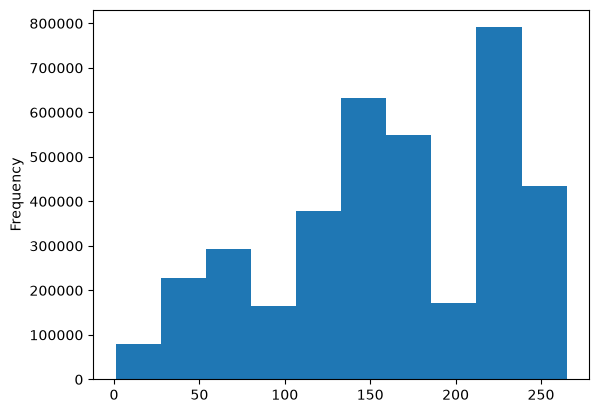

In [89]:
yellow_taxi_jan_2026['PULocationID'].plot(kind='hist')

-- DOLocationID

In [92]:
yellow_taxi_jan_2026['PULocationID'].describe()

count    3.724889e+06
mean     1.614372e+02
std      6.706657e+01
min      1.000000e+00
25%      1.140000e+02
50%      1.610000e+02
75%      2.330000e+02
max      2.650000e+02
Name: PULocationID, dtype: float64

<Axes: ylabel='Frequency'>

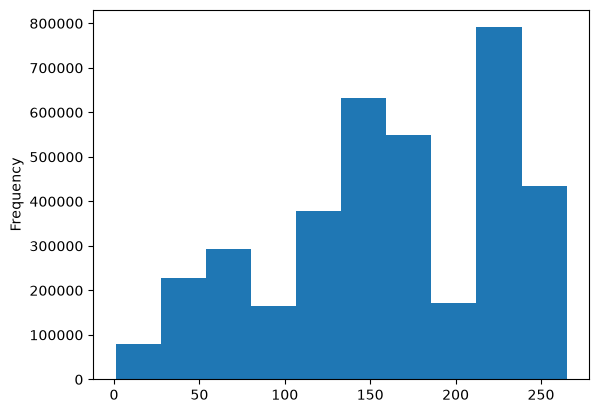

In [91]:
yellow_taxi_jan_2026['PULocationID'].plot(kind='hist')

-- payment_type

In [96]:
yellow_taxi_jan_2026['payment_type'].describe()

count    3.724889e+06
mean     8.465637e-01
std      7.120493e-01
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      4.000000e+00
Name: payment_type, dtype: float64

In [97]:
yellow_taxi_jan_2026['payment_type'].value_counts(dropna=False)

payment_type
1    2249747
0    1088058
2     314043
4      56400
3      16641
Name: count, dtype: int64

-- fare_amount

In [99]:
yellow_taxi_jan_2026['fare_amount'].describe()

count    3.724889e+06
mean     2.080425e+01
std      1.892701e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64

In [100]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['fare_amount']<0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2014534,2,2026-01-23 20:26:52,2026-01-23 20:46:56,2.0,8.74,1.0,N,70,238,4,-35.9,-6.0,-0.5,0.0,-7.46,-1.0,-55.11,-2.5,-1.75,0.00
2462916,2,2026-01-30 08:36:06,2026-01-30 08:36:47,1.0,0.06,1.0,N,141,141,4,-3.0,0.0,-0.5,0.0,0.00,-1.0,-7.00,-2.5,0.00,0.00
2342645,2,2026-01-28 21:59:12,2026-01-28 21:59:23,1.0,0.00,1.0,N,229,229,2,-3.0,-1.0,-0.5,0.0,0.00,-1.0,-8.75,-2.5,0.00,-0.75
1295439,2,2026-01-15 22:04:29,2026-01-15 22:21:13,2.0,2.12,1.0,N,142,170,4,-15.6,-1.0,-0.5,0.0,0.00,-1.0,-21.35,-2.5,0.00,-0.75
2053825,2,2026-01-24 10:38:02,2026-01-24 10:46:46,1.0,1.63,1.0,N,239,230,2,-10.7,0.0,-0.5,0.0,0.00,-1.0,-15.45,-2.5,0.00,-0.75
57084,2,2026-01-01 19:18:43,2026-01-01 19:21:16,1.0,0.40,1.0,N,90,68,2,-4.4,-2.5,-0.5,0.0,0.00,-1.0,-11.65,-2.5,0.00,-0.75
475630,2,2026-01-07 11:13:51,2026-01-07 11:15:36,2.0,0.05,1.0,N,179,179,2,-3.7,0.0,-0.5,0.0,0.00,-1.0,-5.20,0.0,0.00,0.00
2197236,2,2026-01-27 10:51:53,2026-01-27 10:57:16,1.0,0.77,1.0,N,186,234,2,-7.2,0.0,-0.5,0.0,-3.00,-1.0,-14.95,-2.5,0.00,-0.75
1503398,2,2026-01-18 10:32:00,2026-01-18 10:32:27,1.0,0.00,1.0,N,79,79,4,-3.0,0.0,-0.5,0.0,0.00,-1.0,-7.75,-2.5,0.00,-0.75
581026,2,2026-01-08 14:35:40,2026-01-08 15:00:21,1.0,6.39,1.0,N,12,48,2,-31.7,0.0,-0.5,0.0,0.00,-1.0,-36.45,-2.5,0.00,-0.75


-- extra

In [103]:
yellow_taxi_jan_2026['extra'].describe()

count    3.724889e+06
mean     1.023055e+00
std      1.707322e+00
min     -7.500000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.500000e+00
max      1.746000e+01
Name: extra, dtype: float64

In [104]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['extra'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1891312,2,2026-01-22 17:44:20,2026-01-22 17:56:25,1.0,0.86,1.0,N,231,211,4,-11.4,-2.5,-0.5,0.0,0.0,-1.0,-18.65,-2.5,0.00,-0.75
1889947,2,2026-01-22 17:53:05,2026-01-22 18:16:58,2.0,6.42,1.0,N,237,88,2,-30.3,-2.5,-0.5,0.0,0.0,-1.0,-37.55,-2.5,0.00,-0.75
987137,2,2026-01-12 20:08:40,2026-01-12 20:40:22,1.0,10.17,1.0,N,132,225,4,-44.3,-1.0,-0.5,0.0,0.0,-1.0,-48.55,0.0,-1.75,0.00
2261513,2,2026-01-27 22:02:21,2026-01-27 22:03:46,1.0,0.00,1.0,N,89,89,3,-3.0,-1.0,-0.5,0.0,0.0,-1.0,-5.50,0.0,0.00,0.00
2350410,2,2026-01-28 22:56:37,2026-01-28 23:17:59,1.0,4.21,1.0,N,249,52,4,-22.6,-1.0,-0.5,0.0,0.0,-1.0,-28.35,-2.5,0.00,-0.75
2347712,2,2026-01-28 22:38:04,2026-01-28 22:54:00,2.0,6.50,1.0,N,97,257,4,-27.5,-1.0,-0.5,0.0,0.0,-1.0,-30.00,0.0,0.00,0.00
53718,2,2026-01-01 18:06:13,2026-01-01 18:23:48,1.0,7.28,1.0,N,138,255,4,-30.3,-7.5,-0.5,0.0,0.0,-1.0,-44.30,-2.5,-1.75,-0.75
1986916,2,2026-01-23 16:45:58,2026-01-23 16:46:05,1.0,0.00,1.0,N,132,132,4,-3.0,-2.5,-0.5,0.0,0.0,-1.0,-8.75,0.0,-1.75,0.00
1279638,2,2026-01-15 20:08:19,2026-01-15 20:12:48,1.0,0.63,1.0,N,170,233,3,-5.8,-1.0,-0.5,0.0,0.0,-1.0,-11.55,-2.5,0.00,-0.75
1295423,2,2026-01-15 22:14:59,2026-01-15 22:21:00,1.0,0.89,1.0,N,79,224,4,-7.9,-1.0,-0.5,0.0,0.0,-1.0,-13.65,-2.5,0.00,-0.75


-- mta_tax

In [111]:
yellow_taxi_jan_2026['mta_tax'].describe()

count    3.724889e+06
mean     4.833766e-01
std      1.145558e-01
min     -5.000000e-01
25%      5.000000e-01
50%      5.000000e-01
75%      5.000000e-01
max      4.750000e+00
Name: mta_tax, dtype: float64

In [107]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['mta_tax'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1978928,2,2026-01-23 15:23:03,2026-01-23 16:32:20,2.0,17.28,2.0,N,68,132,4,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-82.21,-2.5,0.00,-0.75
2564323,2,2026-01-31 09:09:16,2026-01-31 09:17:20,1.0,1.19,1.0,N,161,100,4,-9.3,0.0,-0.5,0.0,0.00,-1.0,-14.05,-2.5,0.00,-0.75
1427388,2,2026-01-17 12:17:02,2026-01-17 12:23:52,2.0,0.87,1.0,N,239,142,4,-7.9,0.0,-0.5,0.0,0.00,-1.0,-11.90,-2.5,0.00,0.00
2498215,2,2026-01-30 15:50:20,2026-01-30 15:56:52,1.0,0.89,1.0,N,186,48,4,-7.9,0.0,-0.5,0.0,0.00,-1.0,-12.65,-2.5,0.00,-0.75
63743,2,2026-01-01 22:29:04,2026-01-01 22:33:58,1.0,1.20,1.0,N,151,236,4,-7.9,-1.0,-0.5,0.0,0.00,-1.0,-10.40,0.0,0.00,0.00
33505,2,2026-01-01 13:27:07,2026-01-01 13:40:24,2.0,1.23,1.0,N,163,186,3,-12.1,0.0,-0.5,0.0,0.00,-1.0,-16.85,-2.5,0.00,-0.75
1394984,2,2026-01-16 23:49:27,2026-01-16 23:49:56,2.0,0.03,1.0,N,237,237,2,-3.0,-1.0,-0.5,0.0,0.00,-1.0,-8.00,-2.5,0.00,0.00
1617507,2,2026-01-19 19:25:14,2026-01-19 19:25:59,1.0,0.00,1.0,N,262,262,3,-3.0,-2.5,-0.5,0.0,0.00,-1.0,-9.50,-2.5,0.00,0.00
9846,2,2026-01-01 01:48:02,2026-01-01 01:53:26,2.0,0.17,2.0,N,234,90,2,-70.0,0.0,-0.5,0.0,0.00,-1.0,-74.75,-2.5,0.00,-0.75
1469665,2,2026-01-17 20:12:52,2026-01-17 20:13:03,1.0,0.00,1.0,N,132,132,2,-3.0,-1.0,-0.5,0.0,0.00,-1.0,-7.25,0.0,-1.75,0.00


-- tip_amount

In [110]:
yellow_taxi_jan_2026['tip_amount'].describe()

count    3.724889e+06
mean     2.608142e+00
std      3.917405e+00
min     -8.888000e+01
25%      0.000000e+00
50%      2.000000e+00
75%      3.710000e+00
max      7.660000e+02
Name: tip_amount, dtype: float64

In [114]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['tip_amount'] > 200].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
906758,2,2026-01-11 22:43:24,2026-01-11 22:43:27,1.0,0.00,1.0,N,61,264,1,3.0,1.0,0.5,489.99,0.0,1.0,495.49,0.0,0.0,0.00
407839,2,2026-01-06 15:21:45,2026-01-06 15:42:13,6.0,2.34,1.0,N,142,170,1,18.4,0.0,0.5,355.00,0.0,1.0,378.15,2.5,0.0,0.75
911299,1,2026-01-12 01:20:23,2026-01-12 01:46:22,1.0,3.30,1.0,N,182,182,1,22.6,1.0,0.5,700.00,0.0,1.0,725.10,0.0,0.0,0.00
1558294,2,2026-01-18 23:52:52,2026-01-18 23:53:00,1.0,0.00,1.0,N,139,264,1,3.0,1.0,0.5,300.00,0.0,1.0,305.50,0.0,0.0,0.00
2585512,1,2026-01-31 14:22:29,2026-01-31 15:01:33,1.0,1.50,1.0,N,78,248,1,31.7,0.0,0.5,766.00,0.0,1.0,799.20,0.0,0.0,0.00
776307,2,2026-01-10 15:19:36,2026-01-10 15:19:46,1.0,0.00,1.0,N,265,265,1,3.0,0.0,0.0,221.00,0.0,1.0,225.00,0.0,0.0,0.00
56234,2,2026-01-01 19:56:59,2026-01-01 19:57:04,1.0,0.00,1.0,N,61,264,1,3.0,2.5,0.5,218.00,0.0,1.0,225.00,0.0,0.0,0.00
962774,1,2026-01-12 16:34:06,2026-01-12 16:39:11,2.0,0.70,1.0,N,142,142,1,5.8,5.0,0.5,630.45,0.0,1.0,642.75,2.5,0.0,0.00
130176,2,2026-01-02 20:33:05,2026-01-02 20:33:13,1.0,0.00,1.0,N,61,264,1,3.0,1.0,0.5,240.00,0.0,1.0,245.50,0.0,0.0,0.00
813653,1,2026-01-10 21:07:51,2026-01-10 21:09:33,1.0,0.00,3.0,N,83,83,1,23.7,1.0,0.0,227.00,97.3,1.0,350.00,0.0,0.0,0.00


-- tolls_amount

In [117]:
yellow_taxi_jan_2026['tolls_amount'].describe()

count    3.724889e+06
mean     4.983751e-01
std      2.131731e+00
min     -9.450000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.222200e+02
Name: tolls_amount, dtype: float64

In [119]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['tolls_amount'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2075184,2,2026-01-24 14:27:31,2026-01-24 15:15:27,1.0,17.26,2.0,N,132,114,2,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-82.21,-2.5,0.00,-0.75
724591,2,2026-01-09 22:53:56,2026-01-09 22:55:49,1.0,0.00,2.0,N,123,123,4,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-78.96,0.0,0.00,0.00
1028485,2,2026-01-13 12:41:56,2026-01-13 12:55:13,1.0,1.65,1.0,N,170,113,4,-13.5,0.0,-0.5,0.0,-10.00,-1.0,-28.25,-2.5,0.00,-0.75
1253448,2,2026-01-15 16:04:05,2026-01-15 17:15:59,1.0,21.66,1.0,N,132,261,4,-88.4,-2.5,-0.5,0.0,-7.46,-1.0,-104.86,-2.5,-1.75,-0.75
2473046,2,2026-01-30 11:45:20,2026-01-30 12:20:40,1.0,10.58,1.0,N,138,249,4,-48.5,-5.0,-0.5,0.0,-7.46,-1.0,-67.46,-2.5,-1.75,-0.75
256434,2,2026-01-04 14:41:23,2026-01-04 15:32:23,1.0,15.80,5.0,N,230,132,4,-80.0,0.0,0.0,0.0,-6.94,-1.0,-91.19,-2.5,0.00,-0.75
1687888,2,2026-01-20 16:41:01,2026-01-20 17:44:06,1.0,18.35,2.0,N,132,107,4,-70.0,-5.0,-0.5,0.0,-6.94,-1.0,-88.44,-2.5,-1.75,-0.75
2247019,2,2026-01-27 19:44:43,2026-01-27 20:27:09,1.0,17.55,2.0,N,132,162,4,-70.0,-5.0,-0.5,0.0,-7.46,-1.0,-88.96,-2.5,-1.75,-0.75
396806,2,2026-01-06 12:43:34,2026-01-06 13:05:39,2.0,11.79,2.0,N,239,241,4,-70.0,0.0,-0.5,0.0,-3.18,-1.0,-77.18,-2.5,0.00,0.00
1605061,2,2026-01-19 17:19:21,2026-01-19 17:55:48,2.0,13.93,1.0,N,170,14,4,-56.2,-2.5,-0.5,0.0,-7.46,-1.0,-70.91,-2.5,0.00,-0.75


-- improvement_surcharge

In [122]:
yellow_taxi_jan_2026['improvement_surcharge'].describe()

count    3.724889e+06
mean     9.479130e-01
std      2.654859e-01
min     -1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: improvement_surcharge, dtype: float64

<Axes: >

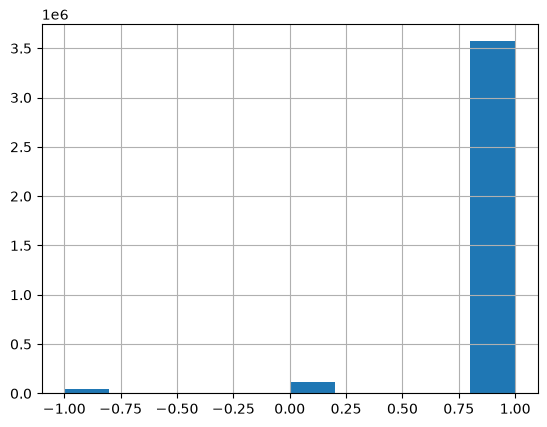

In [123]:
yellow_taxi_jan_2026['improvement_surcharge'].hist()

-- total_amount

In [126]:
yellow_taxi_jan_2026['total_amount'].describe()

count    3.724889e+06
mean     2.917853e+01
std      2.258553e+01
min     -2.560200e+03
25%      1.700000e+01
50%      2.305000e+01
75%      3.383000e+01
max      2.560200e+03
Name: total_amount, dtype: float64

In [136]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['total_amount']>500].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
998250,2,2026-01-13 00:28:08,2026-01-13 02:12:16,3.0,107.42,5.0,N,132,265,2,500.0,0.00,0.0,0.00,0.00,1.0,501.00,0.0,0.00,0.00
73586,2,2026-01-02 08:47:06,2026-01-02 08:47:12,1.0,53.39,1.0,N,193,193,3,629.5,5.75,0.5,0.00,0.00,1.0,636.75,0.0,0.00,0.00
2580146,2,2026-01-31 13:09:41,2026-01-31 13:09:51,1.0,16.04,1.0,N,193,7,4,571.4,4.25,0.5,0.00,0.00,1.0,577.15,0.0,0.00,0.00
1047855,2,2026-01-13 15:56:23,2026-01-13 18:32:02,3.0,81.56,4.0,N,132,265,4,523.1,0.00,0.0,0.00,24.25,1.0,550.85,0.0,1.75,0.75
2824093,2,2026-01-07 19:53:17,2026-01-07 23:11:23,NaN,178.38,NaN,NaN,107,265,0,530.8,0.00,0.0,0.00,17.46,1.0,634.00,NaN,NaN,0.75
962774,1,2026-01-12 16:34:06,2026-01-12 16:39:11,2.0,0.70,1.0,N,142,142,1,5.8,5.00,0.5,630.45,0.00,1.0,642.75,2.5,0.00,0.00
1567007,1,2026-01-19 08:56:33,2026-01-19 13:34:14,1.0,53.60,5.0,N,163,138,1,450.0,5.75,0.0,99.15,39.04,1.0,594.94,0.0,0.00,0.75
51566,2,2026-01-01 18:37:42,2026-01-01 20:00:20,1.0,84.57,4.0,N,132,265,2,466.4,2.50,0.0,0.00,29.94,1.0,501.59,0.0,1.75,0.00
1015926,2,2026-01-13 10:00:11,2026-01-13 11:59:56,1.0,99.93,4.0,N,132,265,2,601.5,0.00,0.0,0.00,49.71,1.0,652.21,0.0,0.00,0.00
1252822,2,2026-01-15 16:27:21,2026-01-15 19:02:47,1.0,97.79,4.0,N,132,265,2,545.5,2.50,0.0,0.00,0.00,1.0,550.75,0.0,1.75,0.00


-- congestion_surcharge

In [138]:
yellow_taxi_jan_2026['congestion_surcharge'].describe()

count    2.636831e+06
mean     2.154870e+00
std      9.423645e-01
min     -2.500000e+00
25%      2.500000e+00
50%      2.500000e+00
75%      2.500000e+00
max      2.500000e+00
Name: congestion_surcharge, dtype: float64

In [139]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['congestion_surcharge'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1640306,2,2026-01-20 08:10:52,2026-01-20 08:15:00,1.0,0.50,1.0,N,237,236,3,-5.8,0.0,-0.5,0.0,0.0,-1.0,-9.80,-2.5,0.0,0.00
174559,2,2026-01-03 14:58:31,2026-01-03 14:58:44,1.0,0.01,1.0,N,170,170,2,-3.0,0.0,-0.5,0.0,0.0,-1.0,-7.75,-2.5,0.0,-0.75
1792535,2,2026-01-21 17:06:58,2026-01-21 17:12:07,2.0,0.00,5.0,N,90,90,4,-6.5,0.0,0.0,0.0,0.0,-1.0,-10.75,-2.5,0.0,-0.75
2595662,2,2026-01-31 16:13:10,2026-01-31 16:13:21,1.0,0.00,1.0,N,237,237,4,-3.0,0.0,-0.5,0.0,0.0,-1.0,-7.00,-2.5,0.0,0.00
286932,2,2026-01-04 22:48:31,2026-01-04 23:00:55,1.0,4.12,1.0,N,144,236,4,-17.7,-1.0,-0.5,0.0,0.0,-1.0,-23.45,-2.5,0.0,-0.75
686037,2,2026-01-09 16:48:53,2026-01-09 16:56:45,1.0,0.95,1.0,N,137,107,4,-8.6,-2.5,-0.5,0.0,0.0,-1.0,-15.85,-2.5,0.0,-0.75
1021990,2,2026-01-13 11:49:55,2026-01-13 11:59:01,1.0,0.89,1.0,N,230,142,4,-10.0,0.0,-0.5,0.0,0.0,-1.0,-14.75,-2.5,0.0,-0.75
302886,2,2026-01-05 09:31:36,2026-01-05 09:34:37,1.0,0.61,1.0,N,263,75,4,-5.1,0.0,-0.5,0.0,0.0,-1.0,-9.10,-2.5,0.0,0.00
2292129,2,2026-01-28 12:11:31,2026-01-28 12:13:03,1.0,0.04,1.0,N,161,161,3,-3.7,0.0,-0.5,0.0,0.0,-1.0,-8.45,-2.5,0.0,-0.75
123394,2,2026-01-02 19:18:52,2026-01-02 19:27:17,1.0,1.21,1.0,N,142,140,4,-9.3,-2.5,-0.5,0.0,0.0,-1.0,-16.55,-2.5,0.0,-0.75


-- Airport_fee

In [141]:
yellow_taxi_jan_2026['Airport_fee'].describe()

count    2.636831e+06
mean     1.482938e-01
std      5.336714e-01
min     -1.750000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.675000e+01
Name: Airport_fee, dtype: float64

In [145]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['Airport_fee'] < 0 ].sample(15)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
986556,2,2026-01-12 20:34:16,2026-01-12 20:58:09,1.0,11.24,1.0,N,132,82,4,-44.3,-1.0,-0.5,0.0,0.00,-1.0,-48.55,0.0,-1.75,0.00
1621844,2,2026-01-19 20:58:43,2026-01-19 21:17:06,1.0,10.46,1.0,N,132,138,3,-39.4,-6.0,-0.5,0.0,0.00,-1.0,-48.65,0.0,-1.75,0.00
900667,2,2026-01-11 20:37:16,2026-01-11 20:53:27,1.0,8.72,1.0,N,132,56,4,-33.1,-1.0,-0.5,0.0,0.00,-1.0,-37.35,0.0,-1.75,0.00
292773,2,2026-01-05 05:24:32,2026-01-05 05:36:45,1.0,7.53,1.0,N,132,93,4,-28.9,-1.0,-0.5,0.0,0.00,-1.0,-33.15,0.0,-1.75,0.00
2091044,2,2026-01-24 17:49:27,2026-01-24 18:36:09,2.0,27.06,1.0,N,132,52,2,-99.6,0.0,-0.5,0.0,0.00,-1.0,-102.85,0.0,-1.75,0.00
1409253,2,2026-01-17 05:15:36,2026-01-17 05:34:59,1.0,10.70,1.0,N,132,39,2,-42.2,-1.0,-0.5,0.0,0.00,-1.0,-46.45,0.0,-1.75,0.00
290883,2,2026-01-05 00:15:59,2026-01-05 00:40:47,1.0,9.91,1.0,N,138,143,4,-41.5,-6.0,-0.5,0.0,-6.94,-1.0,-60.19,-2.5,-1.75,0.00
484954,2,2026-01-07 13:39:11,2026-01-07 13:39:27,1.0,0.00,1.0,N,132,132,2,-3.0,-1.0,-0.5,0.0,0.00,-1.0,-7.25,0.0,-1.75,0.00
1318485,2,2026-01-16 09:57:35,2026-01-16 10:39:21,1.0,16.77,2.0,N,132,137,4,-70.0,0.0,-0.5,0.0,-7.46,-1.0,-83.96,-2.5,-1.75,-0.75
367252,2,2026-01-06 00:19:50,2026-01-06 00:53:48,2.0,17.62,2.0,N,132,75,2,-70.0,0.0,-0.5,0.0,-6.94,-1.0,-80.19,0.0,-1.75,0.00


-- cbd_congestion_fee

In [144]:
yellow_taxi_jan_2026['cbd_congestion_fee'].describe()

count    3.724889e+06
mean     5.196437e-01
std      3.568099e-01
min     -7.500000e-01
25%      0.000000e+00
50%      7.500000e-01
75%      7.500000e-01
max      7.500000e-01
Name: cbd_congestion_fee, dtype: float64

In [146]:
yellow_taxi_jan_2026[yellow_taxi_jan_2026['cbd_congestion_fee'] < 0].sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
492116,2,2026-01-07 14:46:47,2026-01-07 15:55:21,1.0,17.52,2.0,N,132,230,2,-70.0,0.0,-0.5,0.0,-9.94,-1.0,-86.44,-2.5,-1.75,-0.75
1122034,2,2026-01-14 12:53:51,2026-01-14 13:07:59,1.0,1.17,1.0,N,87,231,4,-13.5,0.0,-0.5,0.0,0.00,-1.0,-18.25,-2.5,0.00,-0.75
2507988,2,2026-01-30 17:55:53,2026-01-30 18:06:23,1.0,0.49,1.0,N,148,114,4,-10.0,-2.5,-0.5,0.0,0.00,-1.0,-17.25,-2.5,0.00,-0.75
45817,2,2026-01-01 16:58:50,2026-01-01 17:00:24,2.0,0.15,1.0,N,114,125,2,-3.7,-2.5,-0.5,0.0,0.00,-1.0,-10.95,-2.5,0.00,-0.75
1960602,2,2026-01-23 12:02:35,2026-01-23 12:43:29,1.0,10.73,1.0,N,138,161,4,-50.6,-5.0,-0.5,0.0,-14.94,-1.0,-77.04,-2.5,-1.75,-0.75
12230,2,2026-01-01 02:57:29,2026-01-01 03:13:43,1.0,3.15,1.0,N,164,232,2,-5.1,-1.0,-0.5,0.0,0.00,-1.0,-10.85,-2.5,0.00,-0.75
2258836,2,2026-01-27 22:50:53,2026-01-27 23:08:42,1.0,4.03,1.0,N,161,41,2,-20.5,-1.0,-0.5,0.0,0.00,-1.0,-26.25,-2.5,0.00,-0.75
713641,2,2026-01-09 20:05:41,2026-01-09 20:06:49,1.0,0.04,1.0,N,261,261,4,-3.7,-2.5,-0.5,0.0,0.00,-1.0,-10.95,-2.5,0.00,-0.75
540521,2,2026-01-07 23:03:49,2026-01-07 23:14:23,1.0,1.51,1.0,N,142,161,3,-10.7,-1.0,-0.5,0.0,0.00,-1.0,-16.45,-2.5,0.00,-0.75
644148,2,2026-01-09 07:52:25,2026-01-09 08:00:41,4.0,1.27,1.0,N,90,113,4,-9.3,0.0,-0.5,0.0,0.00,-1.0,-14.05,-2.5,0.00,-0.75


In [147]:
yellow_taxi_jan_2026.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')